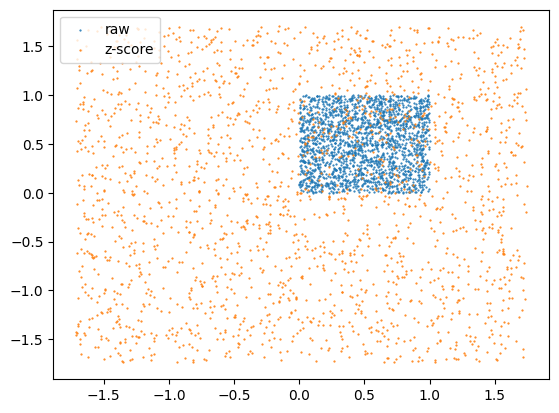

In [19]:
from pinnpy.preprocessing import normalization
import torch
import matplotlib.pyplot as plt


def scatter(x, size=0.3, label=None):
    data = x.detach().cpu().numpy()
    plt.scatter(data[:, 0:1], data[:, 1:2], s=size, label=label)
    plt.legend()

data = torch.rand(2000, 2)
scatter(data, label='raw')

z_norm = normalization.ZScoreNormalizer().fit(data)
z_data = z_norm.transform(data)
scatter(z_data, label='z-score')



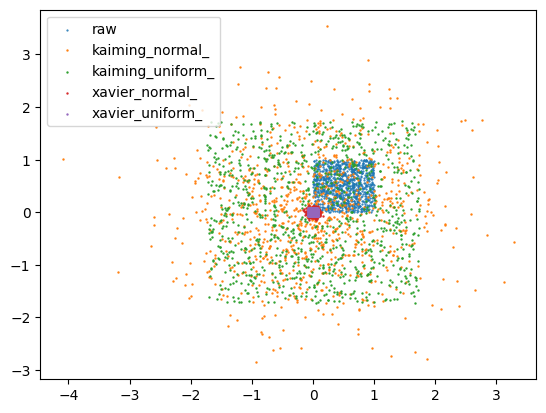

In [27]:
import torch.nn.init as init
import inspect
import torch

# initializations = {}
# for name, func in inspect.getmembers(init, inspect.isfunction):
#     if name.endswith('_'):
#         initializations[name] = func
# t_raw = torch.rand([1000, 2], dtype=torch.float32)
# scatter(t_raw, label='raw')

# for k, v in initializations.items():
#     try:
#         t_init = t_raw.clone()
#         t_init = v(t_raw)
#         scatter(t_init, label=k, size=0.5)
#     except Exception as e:
        # print(f"Skipping {k}: Needs extra arguments or different shape.")

inits = ['kaiming_normal_', 'kaiming_uniform_', 'xavier_normal_', 'xavier_uniform_']

t_raw = torch.rand([1000, 2], dtype=torch.float32)
scatter(t_raw, label='raw')

for name in inits:
    init_func = getattr(init, name)
    t_norm = init_func(t_raw)
    scatter(t_norm, 0.5, name)


In [ ]:
initializations = []
for name in dir(torch.nn.init):
    if name.endswith('_'):
        initializations.append(torch.nn.init.name)

['Callable',
 'Literal',
 'ParamSpec',
 'Tensor',
 'TypeVar',
 'Union',
 '_FanMode',
 '_NonlinearityType',
 '_Optional',
 '_P',
 '_R',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_calculate_correct_fan',
 '_calculate_fan_in_and_fan_out',
 '_make_deprecate',
 '_no_grad_fill_',
 '_no_grad_normal_',
 '_no_grad_trunc_normal_',
 '_no_grad_uniform_',
 '_no_grad_zero_',
 'calculate_gain',
 'constant',
 'constant_',
 'dirac',
 'dirac_',
 'eye',
 'eye_',
 'kaiming_normal',
 'kaiming_normal_',
 'kaiming_uniform',
 'kaiming_uniform_',
 'math',
 'normal',
 'normal_',
 'ones_',
 'orthogonal',
 'orthogonal_',
 'sparse',
 'sparse_',
 'torch',
 'trunc_normal_',
 'uniform',
 'uniform_',
 'warnings',
 'xavier_normal',
 'xavier_normal_',
 'xavier_uniform',
 'xavier_uniform_',
 'zeros_']